In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv('../data/comprovantes_pix_10000_anomalias.csv', sep=';')

In [3]:
df['DataHora'] = pd.to_datetime(df['DataHora'], errors='coerce')
df['Hora_Transacao'] = df['DataHora'].dt.hour
df['Dia_Semana'] = df['DataHora'].dt.dayofweek
df['Fim_de_Semana'] = df['Dia_Semana'].apply(lambda x: 1 if x >= 5 else 0)
df['Horario_Comercial'] = df['Hora_Transacao'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

In [4]:
df.columns

Index(['EndToEndId', 'DataHora', 'Valor', 'Moeda', 'Pagador_Nome',
       'Pagador_CPF_CNPJ', 'Pagador_Banco', 'Recebedor_Nome',
       'Recebedor_CPF_CNPJ', 'Recebedor_Banco', 'ChavePix_Utilizada',
       'TipoChave', 'Descricao', 'Status', 'Anomalia', 'Hora_Transacao',
       'Dia_Semana', 'Fim_de_Semana', 'Horario_Comercial'],
      dtype='str')

In [5]:
#Mantendo apenas variáveis relevantes para o modelo
relevantes = [
'EndToEndId',  
'DataHora', 
'Hora_Transacao',
'Dia_Semana', 
'Fim_de_Semana', 
'Horario_Comercial',
'Pagador_Banco', 
'Recebedor_Banco', 
'TipoChave', 
'Status',
'Valor'
]

df02 = df[relevantes].copy()

In [16]:
df02.head()

,EndToEndId,DataHora,Hora_Transacao,Dia_Semana,Fim_de_Semana,Horario_Comercial,Pagador_Banco,Recebedor_Banco,TipoChave,Status,Valor
0,f094cb2c-2a73-463c-b60e-0c57262051e4,2025-06-26 21:07:56,21.0,3.0,0,0,BTG Pactual,Nubank,Telefone,Concluída,4658.86
1,f0409769-741f-49bd-811a-3842cc8f54db,2025-06-23 17:47:56,17.0,0.0,0,1,Banco do Brasil,Itaú Unibanco,Telefone,Pendente,3184.72
2,c1d22287-d343-4c91-b03d-dbe9a69695b3,2025-06-27 15:58:56,15.0,4.0,0,1,Banco Inter,Bradesco,Chave Aleatória,Pendente,1054.48
3,254423a9-50b7-41b1-a099-e8cf6232bab4,2025-07-15 13:59:56,13.0,1.0,0,1,Banco Safra,Caixa Econômica Federal,E-mail,Estornada,3564.76
4,f1c5e3e7-bc62-4f18-91e3-c8f92aebdd59,2025-06-23 06:19:56,6.0,0.0,0,0,Santander Brasil,C6 Bank,E-mail,Pendente,15.16


Os gráficos abaixo, tanto o boxplot quanto os graficos de barras mostram que o dataset está bem balanceado, isso se mostra verdade para todas as variáveis analisadas, seja o valor da transação que é o unico valor numérico ou as demais variáveis categóricas.
No entanto é percebido uma quebra desse padrão ao analisar a coluna Recebedor_Banco que possui uma categoria com menos ocorrências que as demais, abaixo vamos explorar um pouco mais essa constatação.

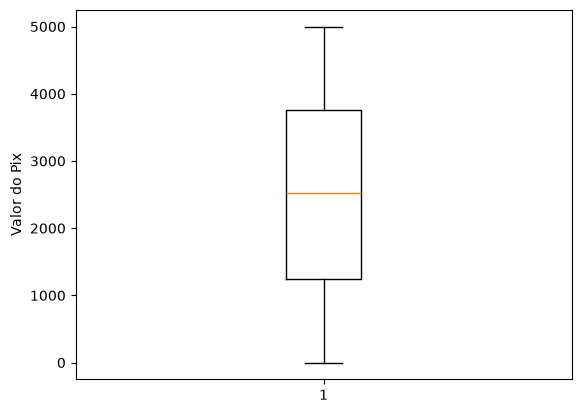

In [8]:
plt.boxplot(df02['Valor'])
plt.ylabel('Valor do Pix')
plt.show()

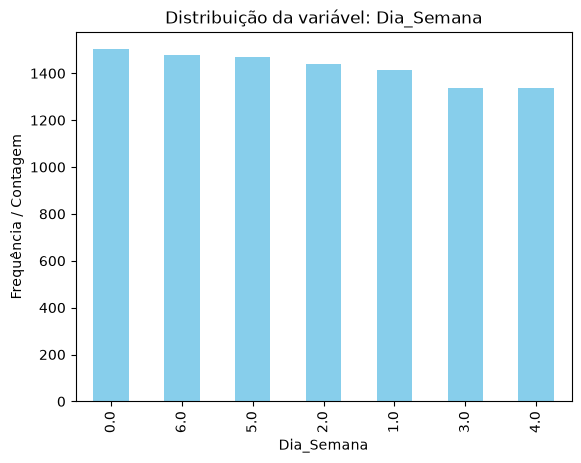

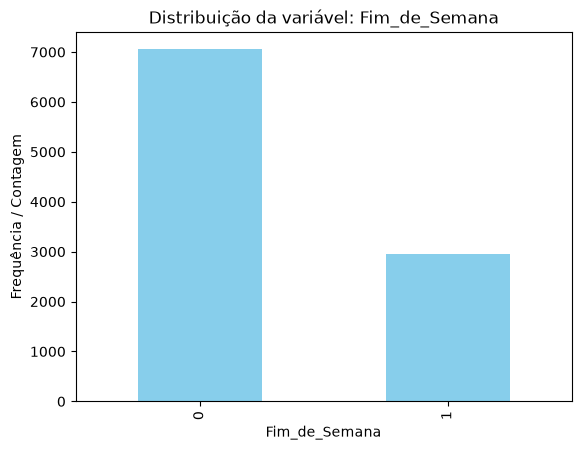

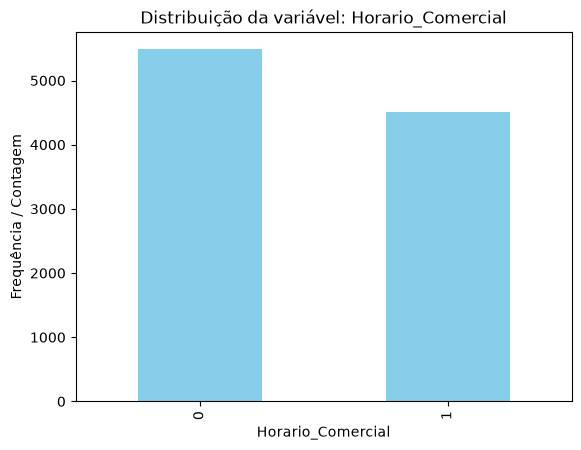

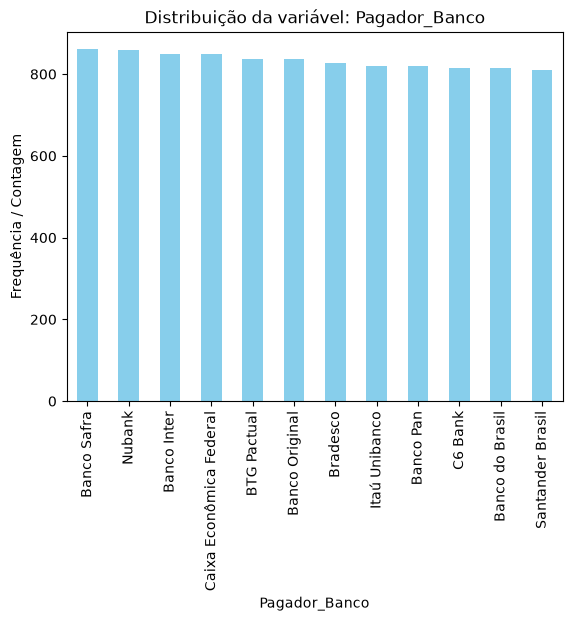

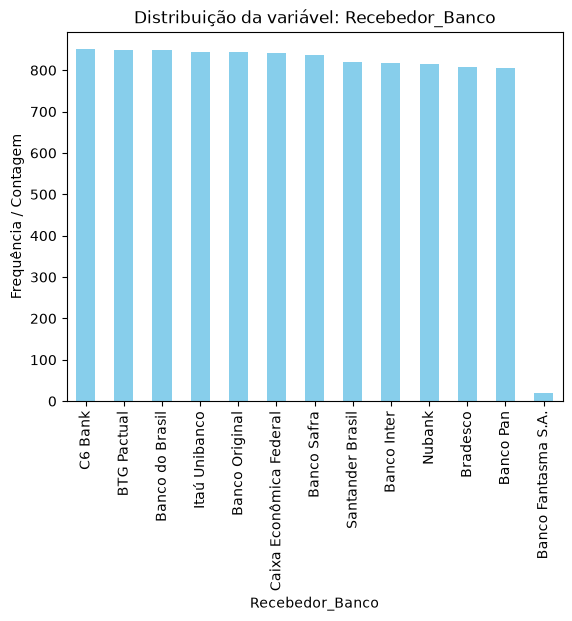

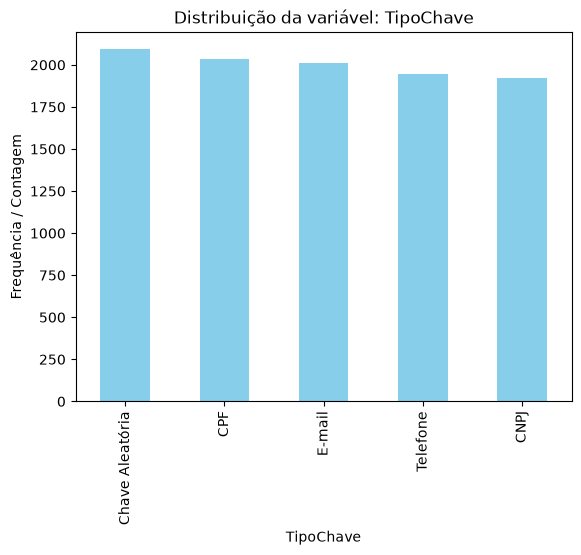

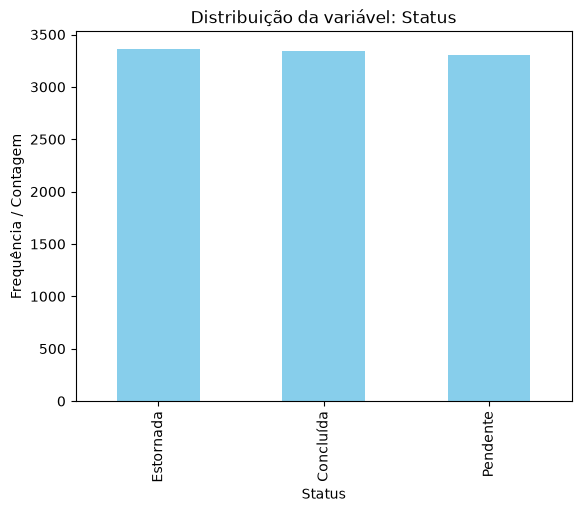

In [10]:
categ_list = ['Dia_Semana', 'Fim_de_Semana', 'Horario_Comercial', 'Pagador_Banco', 'Recebedor_Banco', 'TipoChave', 'Status']

for var in categ_list:
    plt.figure() 
    df02[var].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribuição da variável: {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência / Contagem')
    plt.show()

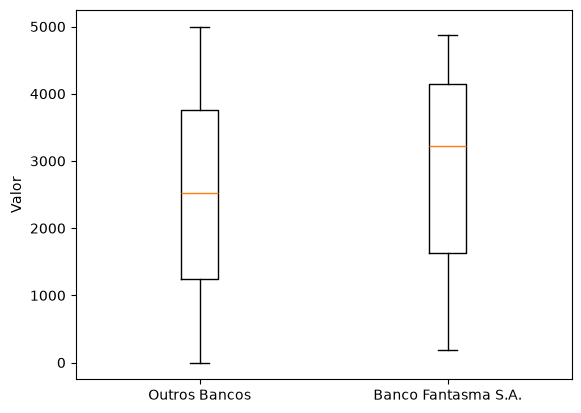

In [12]:
fantasma = df02[df02['Recebedor_Banco'] == 'Banco Fantasma S.A.']['Valor']
outros = df02[df02['Recebedor_Banco'] != 'Banco Fantasma S.A.']['Valor']

plt.boxplot([outros, fantasma], tick_labels=['Outros Bancos', 'Banco Fantasma S.A.'])
plt.ylabel('Valor')
plt.show()

Ao observar a distribuição da variável Recebedor_Banco percebemos que existe uma categoria chamada Banco Fantasma, essa categoria diferentemente das demais tem poucas ocorrências e tem um valor de transação acima do padrão, além disso percebemos que ao analisar outras variáveis considerando apenas esses casos suspeitos nos deparamos com um cenário levemente diferente do normal, com mais casos de transações pendentes olhando o status e também com uma maior concentração de casos realizados com chave pix tipo aleatória e telefone, as demais variáveis não parecem fora do comum. 

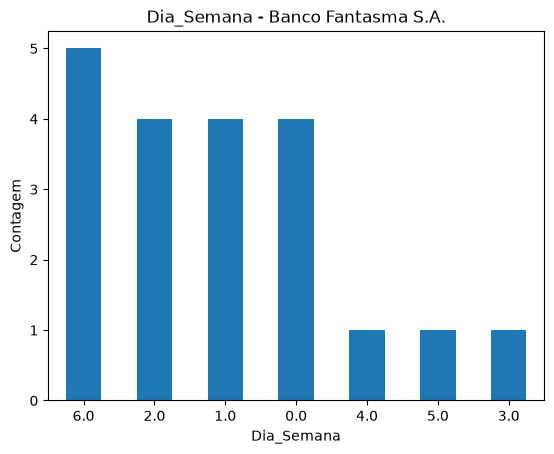

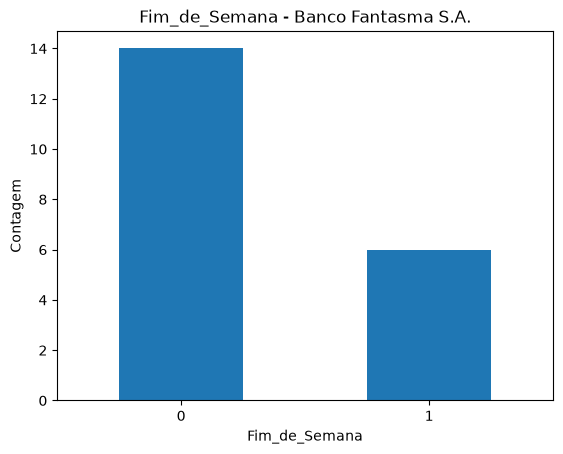

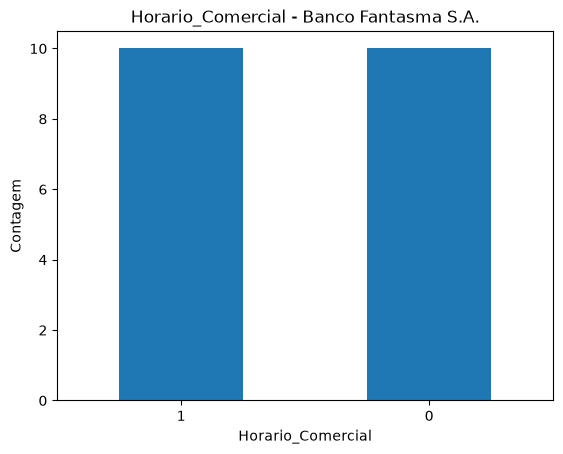

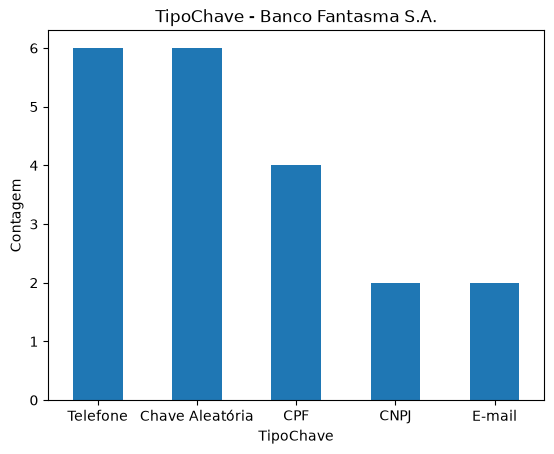

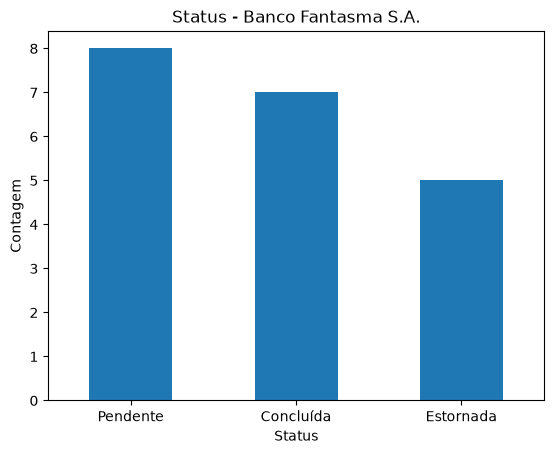

In [14]:
df_fantasma = df02[df02['Recebedor_Banco'] == 'Banco Fantasma S.A.']
variaveis = ['Dia_Semana', 'Fim_de_Semana', 'Horario_Comercial', 'TipoChave', 'Status']

for var in variaveis:
    plt.figure()
    df_fantasma[var].value_counts().plot(kind='bar')
    plt.title(f'{var} - Banco Fantasma S.A.')
    plt.ylabel('Contagem')
    plt.xticks(rotation=0)
    plt.show()

Não foi feito normalização pois temos apenas uma variável numérica que é o valor da transação então não temos o problema de ter variáveis em escalas diferentes.

Não foi aplicado o PCA pois ele não é uma abordagem que faz sentido em um cenário onde temos muitas variáveis categóricas e apenas uma numérica, iremos buscar na literatura técnicas outras metodologias.

Não foi aplicado a análise de correlação pelo mesmo motivo, como temos apenas uma variável numérica, não temos como calcular correlações entre variáveis numéricas. Para as variáveis categóricas, podemos analisar a relação entre elas e a variável alvo (anormalidade) usando técnicas como tabelas de contingência ou testes estatísticos, mas isso não se encaixa na definição tradicional de análise de correlação, nesse caso buscaremos na literatura outra maneira de analisar as relações entre as variáveis além da analise exploratoria.